
# 🌌 SpecCLIP Demo

**Authors:** Xiaosheng Zhao (JHU)

This notebook demonstrates how to:
1. Load the pretrained **SpecCLIP** model and all downstream-models from Hugging Face  
2. Predict stellar parameters from an input spectrum (coming soon)
3. Retrieve similar stars using a precomputed embedding index
4. Predict cross-modal spectra given a query spectra

> 🧭 **Paper:** [SpecCLIP: Aligning and Translating Spectroscopic Measurements for Stars](https://arxiv.org/abs/2507.01939)


For debugging:

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

import torch

if torch.cuda.is_available():
    print("GPU is available.")
    # You can also get the name of the GPU
    print(f"GPU Name: {torch.cuda.get_device_name(0)}") 
else:
    print("No GPU available. PyTorch will run on CPU.")

GPU is available.
GPU Name: Tesla V100-SXM2-16GB


### Download Models at once

**First set the path of LOCAL_MODEL_DIR in download_and_setup.py to download models and/or test data**

In [ ]:
# Step 1: Install required packages
#!pip install -q huggingface_hub

# Step 2: Authenticate with HuggingFace
from huggingface_hub import login
import os

print("=" * 70)
print("HuggingFace Authentication")
print("=" * 70)
print("\nTo download the models, you need a HuggingFace token.")
print("Get your token from: https://huggingface.co/settings/tokens")
print("\nMake sure to select 'Read' permission when creating the token.")
print("=" * 70)

# Option 1: Interactive login (will prompt for token)
try:
    #login()
    #Login with token directly
    login(token="YOUR TOKEN")
    print("\n✓ Authentication successful!")
except Exception as e:
    print(f"\n✗ Authentication failed: {e}")
    print("\nAlternatively, you can:")
    print("  1. Run in terminal: huggingface-cli login")
    print("  2. Or set token: login(token='hf_your_token_here')")

# Step 3: Download models
print("\n" + "=" * 70)
print("Downloading Models and/or Test Data")
print("=" * 70)
# Option A: Full download (models + test data) for retrieval tasks
#!python download_and_setup.py --include-test-data

# Option B: Models only (faster, for parameter estimation only)
!python download_and_setup.py

# Option C: Test data only (if you already downloaded models)
# !python download_and_setup.py --test-data-only

print("\n✓ Setup complete! You can now use the models and test data.")

## Predict Stellar Parameters

🚧 *This part is under development and will be added soon.*
---

## Similar-Star Retrieval & Cross-Modal Predictions (embeddings)
Spectral Retrieval and Cross-Modal Analysis

### Summary of All Tasks

| Task |  Description |
|------|-------------|
| 1 | Build embedding database from test set |
| 2 | In-modal retrieval from test set (verify top-1 is self) |
| 3 | In-modal retrieval with external spectra |
| 4 | Cross-modal retrieval from test set (verify top-1 is paired) |
| 5 | Cross-modal retrieval with external spectra |
| 6 | Cross-modal prediction for test and external spectra |

* **Note:** Since the LAMOST LRS (continuum-normalized) and Gaia XP (550nm flux-normalized) are not normalized in the same way, even the comparison between the two for the same star may 'look' different.
---

### Setup and Imports

In [127]:
import numpy as np
import matplotlib.pyplot as plt
import json
from spectral_retrieval import SpectralRetriever, get_default_model_paths

# For loading external spectra (reuse from stellar parameter prediction)
from predict_lrs_wclip_v0 import load_spectrum_data
from predict_xp_wclip_v0 import load_spectrum_data as load_spectrum_data_xp

# Display settings
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

# Download est data only (if you already downloaded models); NOTE: THIS IS A SMALL DATASET, SO THAT THE RETRIEVAL TASKS ARE NOT AS GOOD AS IT SHOWS!!
!python download_and_setup.py --test-data-only



Dataset Repository: astroshawn/SpecCLIP-TestData
Local directory: /home/idies/workspace/Temporary/xzhao/scratch/pretrained_models_new/test_data

Downloading: gaia_lamost_test_only.h5
This may take several minutes for large files...

/home/idies/workspace/Storage/xzhao/persistent/miniconda3/envs/astro-ai/lib/python3.10/site-packages/huggingface_hub/file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/home/idies/workspace/Storage/xzhao/persistent/miniconda3/envs/astro-ai/lib/python3.10/site-packages/huggingface_hub/file_download.py:982: UserWarning: `local_dir_use_symlinks` parameter is deprecated and will be ignored. The process to download files to a local folder has been updated and do not rely on symlinks anymore. You only need to pass a destination folder as`local_dir`.
For more details, check out https://hug

### Configuration and Build Embeddings (Task 1)

In [4]:
# Load config (test data path included if downloaded)
with open('config_retrieval.json', 'r') as f:
    config = json.load(f)

print(f"Test data path: {config.get('h5_data_path', 'Not configured')}")

# Initialize retriever; default using SpecCLIP-pr (predrecon) model, it is better at LAMOST LRS -> Gaia XP prediction.
config['use_split_for_retrieval'] = False
retriever = SpectralRetriever(**config)

# Modify paths if needed. e.g. using the SpecCLIP-split model.
#config['use_split_for_retrieval'] = True
#retriever = SpectralRetriever(**config)
print (config)

# Build embedding database from test data
if 'h5_data_path' in config:
    retriever.build_embedding_database(batch_size=1000, save_path='./test_embeddings.npz')  # Save for future use)
else:
    print("⚠️  Test data not available. Download with:")
    print("   !python download_and_setup.py --test-data-only")

Test data path: /home/idies/workspace/Temporary/xzhao/scratch/pretrained_models_new/test_data/gaia_lamost_test_only.h5
Using device: cuda
Loading SpecClip model(s)...


/home/idies/workspace/Storage/xzhao/DESI-workspace/xzhao/SpecCLIP/specclip/models/specclip_reconstruct_embed768_mlp.py:837: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  che

Total trainable parameters: 42,846,129


/home/idies/workspace/Storage/xzhao/DESI-workspace/xzhao/SpecCLIP/specclip/models/specclip_reconstruct_embed768_mlp.py:613: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  che

Total trainable parameters: 42,846,129


...

Models loaded successfully!
{'specclip_predrecon_path': '/home/idies/workspace/Temporary/xzhao/scratch/pretrained_models_new/specclip/specclip_model_predrecon_mlp.ckpt', 'specclip_split_path': '/home/idies/workspace/Temporary/xzhao/scratch/pretrained_models_new/specclip/specclip_model_split_mlp.ckpt', 'xp_encoder_path': '/home/idies/workspace/Temporary/xzhao/scratch/pretrained_models_new/encoders/xp_encoder_mlp.ckpt', 'lrs_encoder_path': '/home/idies/workspace/Temporary/xzhao/scratch/pretrained_models_new/encoders/lrs_encoder.ckpt', 'h5_data_path': '/home/idies/workspace/Temporary/xzhao/scratch/pretrained_models_new/test_data/gaia_lamost_test_only.h5', 'use_split_for_retrieval': False}
Loading test data from /home/idies/workspace/Temporary/xzhao/scratch/pretrained_models_new/test_data/gaia_lamost_test_only.h5
Loaded 82057 test spectra
Generating Gaia XP embeddings...


Processing gaia_spectra: 100% 83/83 [00:00<00:00, 93.39it/s]


Generating LAMOST LRS embeddings...


Processing lamost_spectra: 100% 83/83 [01:27<00:00,  1.05s/it]


✓ Embedding database built successfully!
✓ Saved embeddings to /home/idies/workspace/Temporary/xzhao/scratch/pretrained_models_new/test_data/test_embeddings_pr.npz


Default

### Alternatively, Build Embedding Database and Check (Task 1)

In [ ]:
# Build embedding database from test set
# This will take a few minutes on first run

#!mkdir ./embeddings/

embedding_db = retriever.build_embedding_database(
    batch_size=1000,
    save_path='./test_embeddings.npz'  # Save for future use
)

print(f"\nDatabase Statistics:")
print(f"  Gaia XP spectra: {len(embedding_db['gaia_spectra'])}")
print(f"  LAMOST LRS spectra: {len(embedding_db['lamost_spectra'])}")
print(f"  Gaia embeddings shape: {embedding_db['gaia_embeddings'].shape}")
print(f"  LAMOST embeddings shape: {embedding_db['lamost_embeddings'].shape}")

### Load Pre-built Embeddings (Optional)

In [10]:
# If you've already built the database, load it directly
retriever.load_embeddings('./test_embeddings.npz')

✓ Loaded embeddings from /home/idies/workspace/Temporary/xzhao/scratch/pretrained_models_new/test_data/test_embeddings_pr.npz


### In-Modal Retrieval from Test Set (Task 2)

mkdir: cannot create directory ‘./plots/’: File exists
Query Index: 100
Top match index: 100
Top match score: 1.0000

Is query the top match? True

All match indices: [  100 18433 54323 55690]
All match scores: [0.9999999  0.8962984  0.8910275  0.88055444]
Saved plot to ./plots/lamost_in_modal_query_100.png


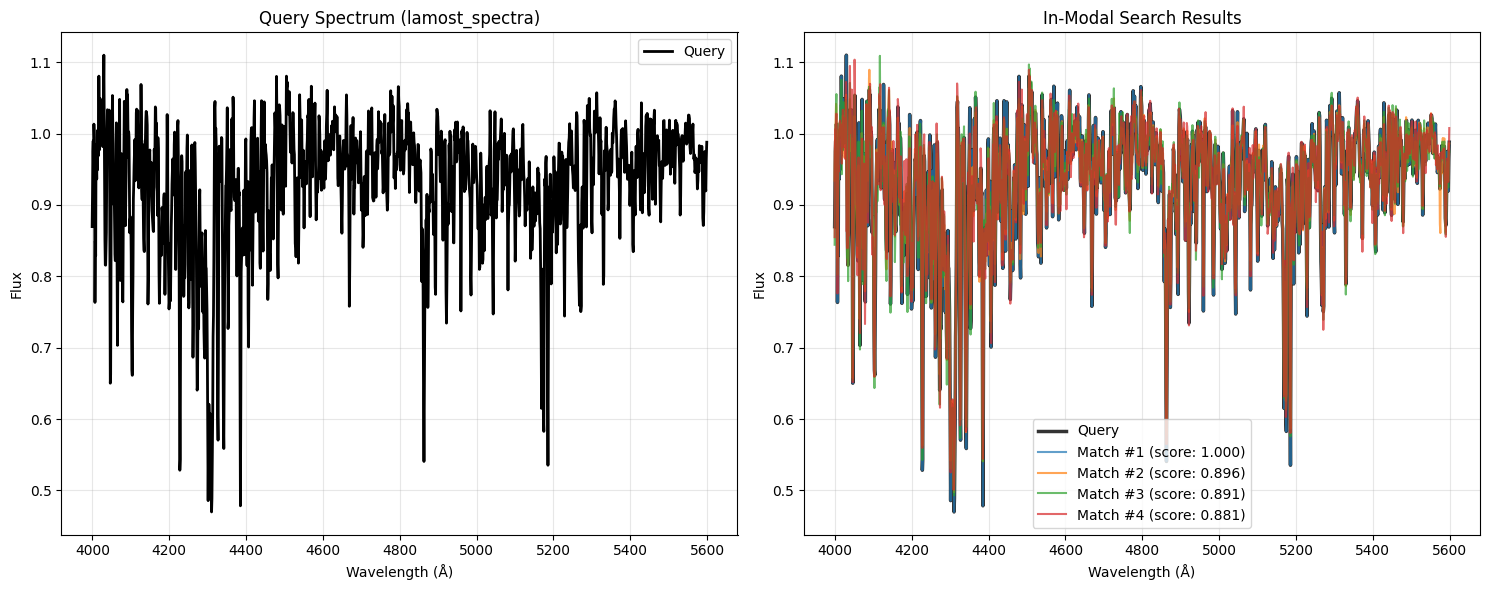

In [6]:
# Query using a spectrum from the test set (by index)
# The top match should be the query itself

!mkdir ./plots/

query_idx = 100  # Example index

# LAMOST in-modal search
results_lamost = retriever.find_similar_spectra(
    query_spectrum=query_idx,
    query_type='lamost_spectra',
    search_type='in_modal',
    top_k=4,
    exclude_self=False  # Include self to verify it's top match
)

print(f"Query Index: {query_idx}")
print(f"Top match index: {results_lamost['top_indices'][0]}")
print(f"Top match score: {results_lamost['top_scores'][0]:.4f}")
print(f"\nIs query the top match? {results_lamost['top_indices'][0] == query_idx}")
print(f"\nAll match indices: {results_lamost['top_indices']}")
print(f"All match scores: {results_lamost['top_scores']}")

# Plot results
retriever.plot_retrieval_results(
    results_lamost,
    save_path=f'./plots/lamost_in_modal_query_{query_idx}.png'
)

### In-Modal Retrieval - Gaia XP (Task 2)

Query Index: 250
Top match index: 250
Is query the top match? True


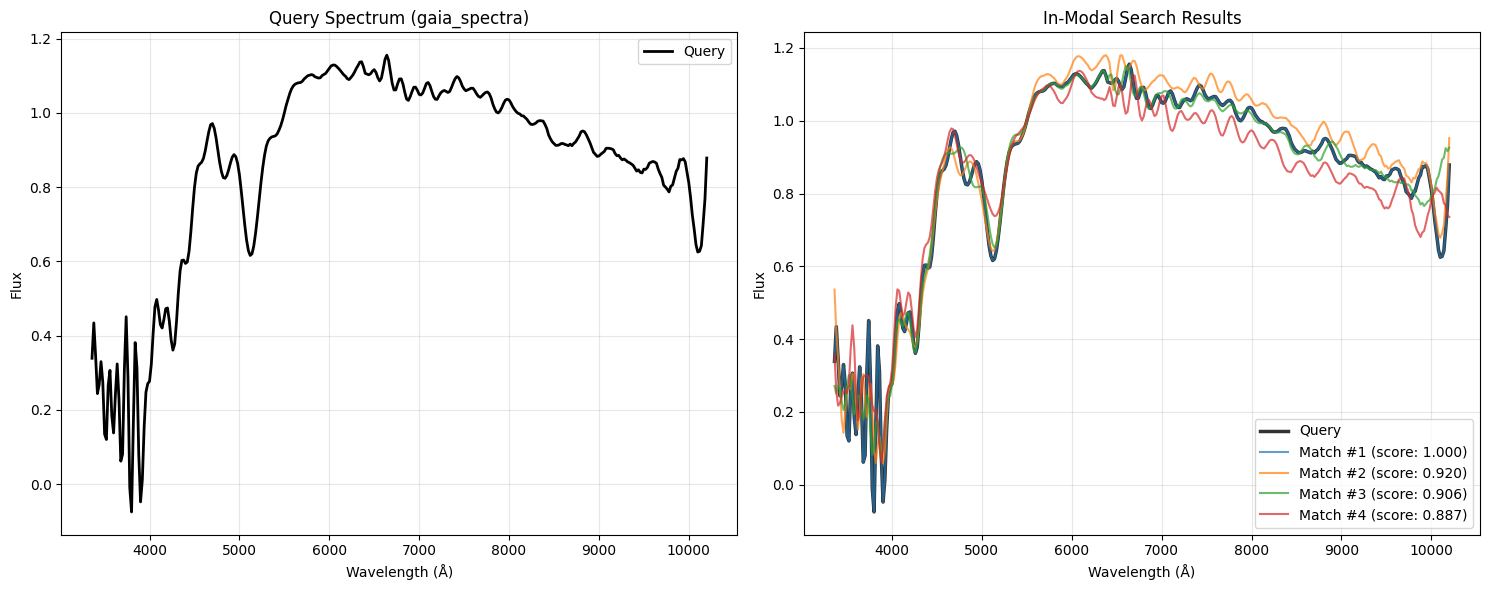

In [7]:
# Same for Gaia XP
query_idx = 250

results_gaia = retriever.find_similar_spectra(
    query_spectrum=query_idx,
    query_type='gaia_spectra',
    search_type='in_modal',
    top_k=4,
    exclude_self=False
)

print(f"Query Index: {query_idx}")
print(f"Top match index: {results_gaia['top_indices'][0]}")
print(f"Is query the top match? {results_gaia['top_indices'][0] == query_idx}")

retriever.plot_retrieval_results(results_gaia)

### External Spectrum In-Modal Retrieval (Task 3)

(3890,)
(3890,)
Top match indices: [ 9848 16229 51601 14498]
Top match scores: [0.9031622  0.8905828  0.88587123 0.8849769 ]

Source IDs of matches:
  Match #1: 1227388029837621504
  Match #2: 3911468433485351040
  Match #3: 1259341968044873472
  Match #4: 1513348391218850944
Saved plot to ./plots/external_lamost_in_modal.png


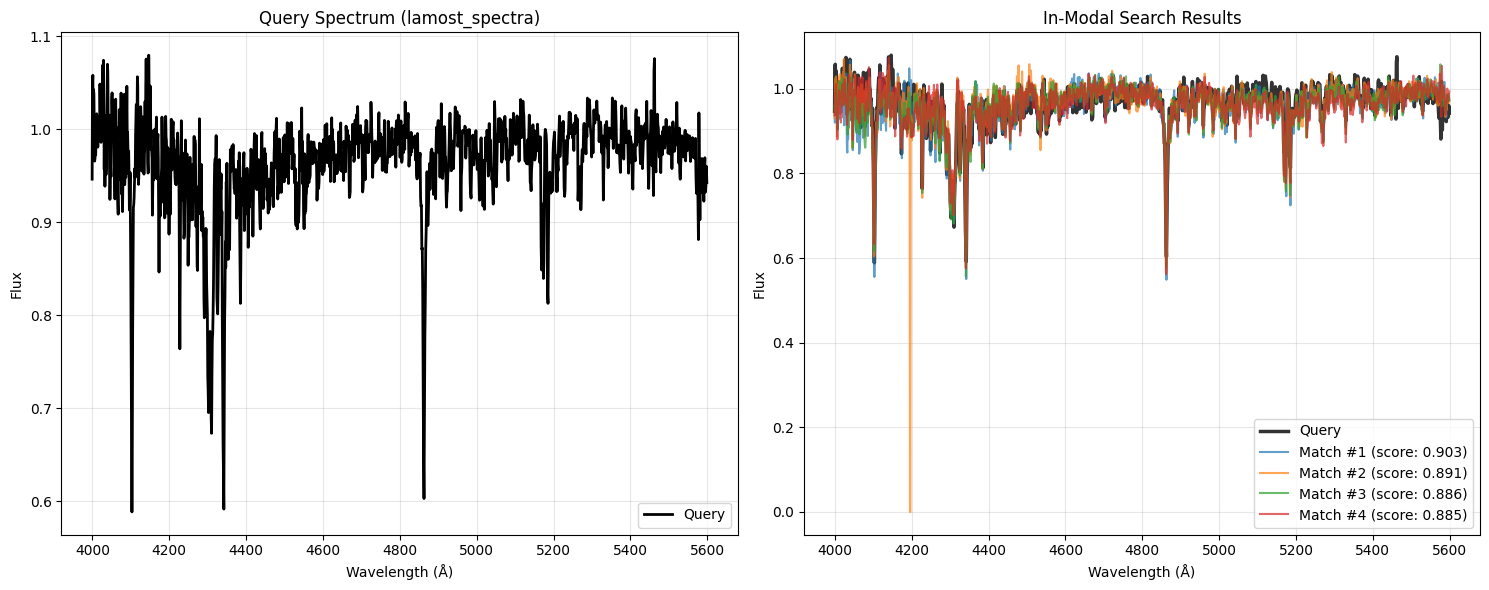

In [73]:
# Load an external LAMOST spectrum
wavelength, flux = load_spectrum_data('./test_data/lrs/spec-55859-F5902_sp02-084.fits.gz')
print (flux.shape)
#wavelength = wavelength.reshape(-1,1)
#flux = flux.reshape(-1,1)
print (flux.shape)

# Find similar spectra
results_external_lamost = retriever.find_similar_spectra(
    query_spectrum=(wavelength, flux),  # Pass as tuple
    query_type='lamost_spectra',
    search_type='in_modal',
    top_k=4
)

print(f"Top match indices: {results_external_lamost['top_indices']}")
print(f"Top match scores: {results_external_lamost['top_scores']}")
print(f"\nSource IDs of matches:")
for i, source_id in enumerate(results_external_lamost['source_ids']):
    print(f"  Match #{i+1}: {source_id}")

# Plot
retriever.plot_retrieval_results(
    results_external_lamost,
    save_path='./plots/external_lamost_in_modal.png'
)

### External Gaia XP Spectrum Retrieval (Task 3)

Top 4 matches found
Scores: [0.95241374 0.9082484  0.89569247 0.8944562 ]


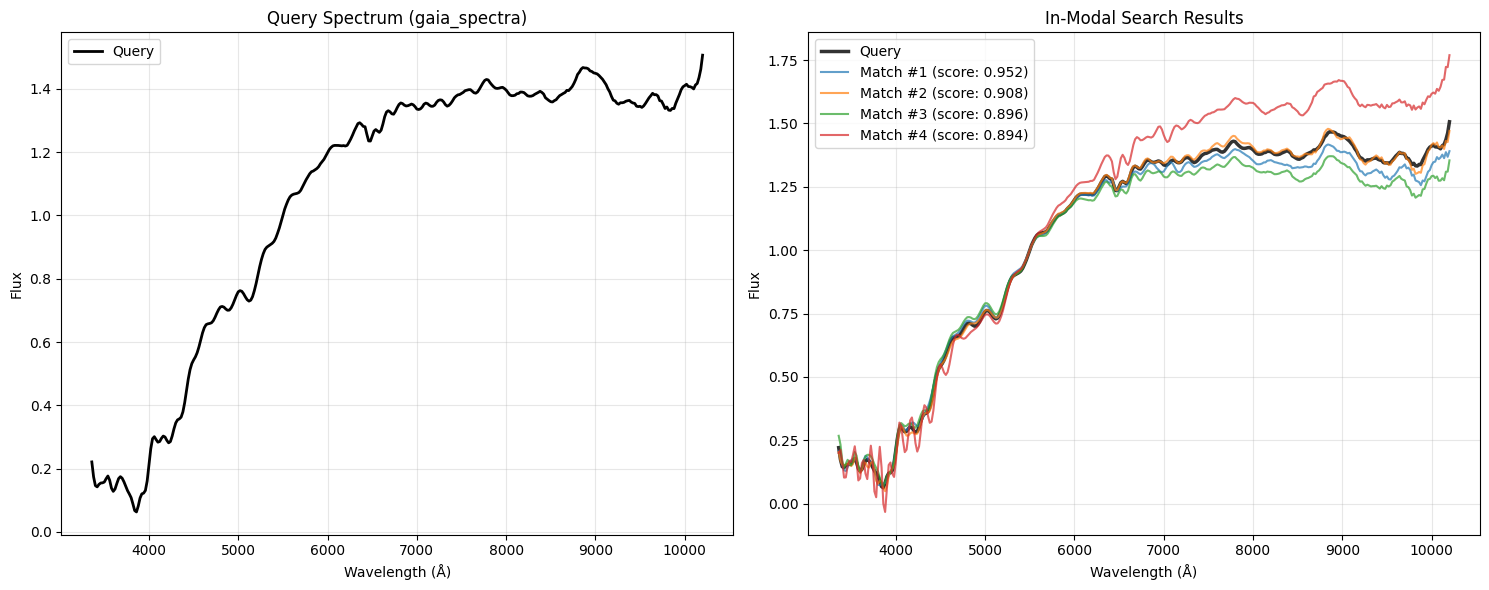

In [13]:
# Load external Gaia XP spectrum
wavelength_xp, flux_xp = load_spectrum_data_xp('./test_data/xp/sample4_txt_xp.csv')

results_external_gaia = retriever.find_similar_spectra(
    query_spectrum=(wavelength_xp, flux_xp),
    query_type='gaia_spectra',
    search_type='in_modal',
    top_k=4
)

print(f"Top {len(results_external_gaia['top_spectra'])} matches found")
print(f"Scores: {results_external_gaia['top_scores']}")

retriever.plot_retrieval_results(results_external_gaia)

### Cross-Modal Retrieval from Test Set (Task 4)

LAMOST Query Index: 114
Top Gaia match index: 114
Top match score: 0.8870

Expected paired index: 114
Is paired spectrum the top match? True
Saved plot to ./plots/lamost_to_gaia_cross_modal_query_114.png


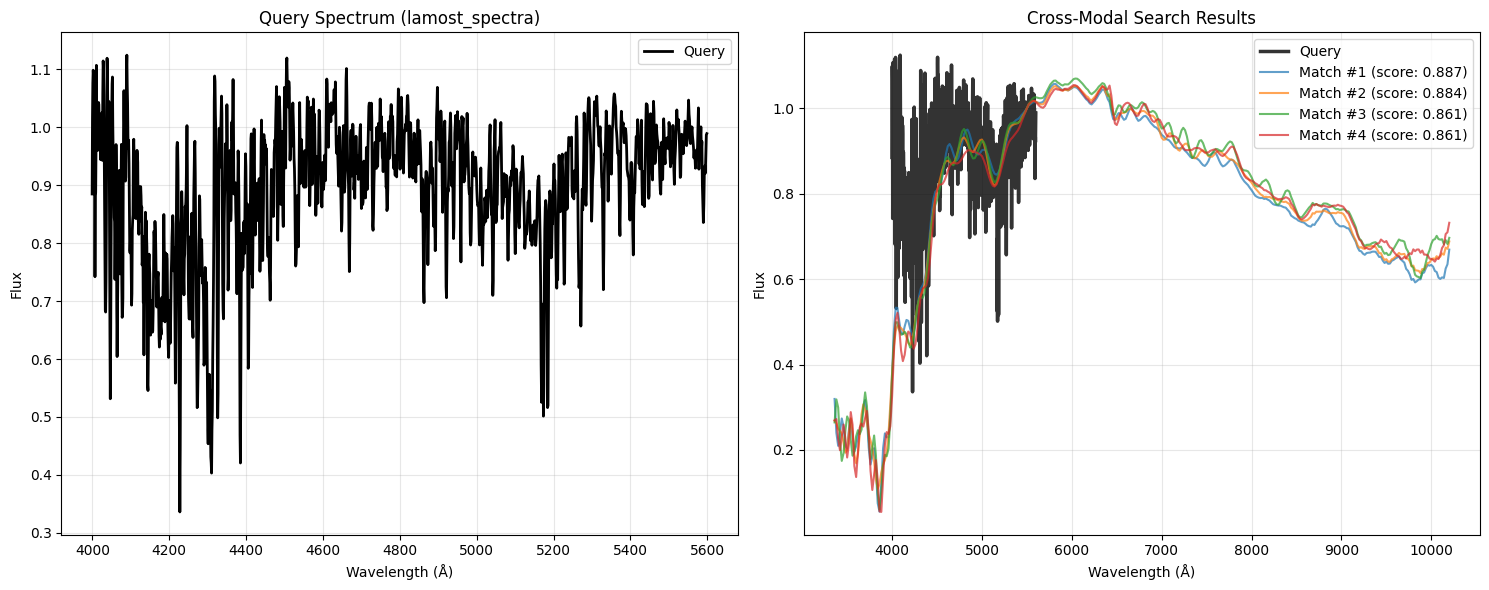

In [14]:
# LAMOST query -> Find similar Gaia XP spectra
query_idx = 114 #100

results_lamost_to_gaia = retriever.find_similar_spectra(
    query_spectrum=query_idx,
    query_type='lamost_spectra',
    search_type='cross_modal',
    top_k=4,
    exclude_self=False
)

print(f"LAMOST Query Index: {query_idx}")
print(f"Top Gaia match index: {results_lamost_to_gaia['top_indices'][0]}")
print(f"Top match score: {results_lamost_to_gaia['top_scores'][0]:.4f}")
print(f"\nExpected paired index: {query_idx}")
print(f"Is paired spectrum the top match? {results_lamost_to_gaia['top_indices'][0] == query_idx}")

retriever.plot_retrieval_results(
    results_lamost_to_gaia,
    save_path=f'./plots/lamost_to_gaia_cross_modal_query_{query_idx}.png'
)

### Cross-Modal Retrieval - Gaia to LAMOST (Task 4)

Gaia Query Index: 104
Top LAMOST match index: 11610
Is paired spectrum the top match? False


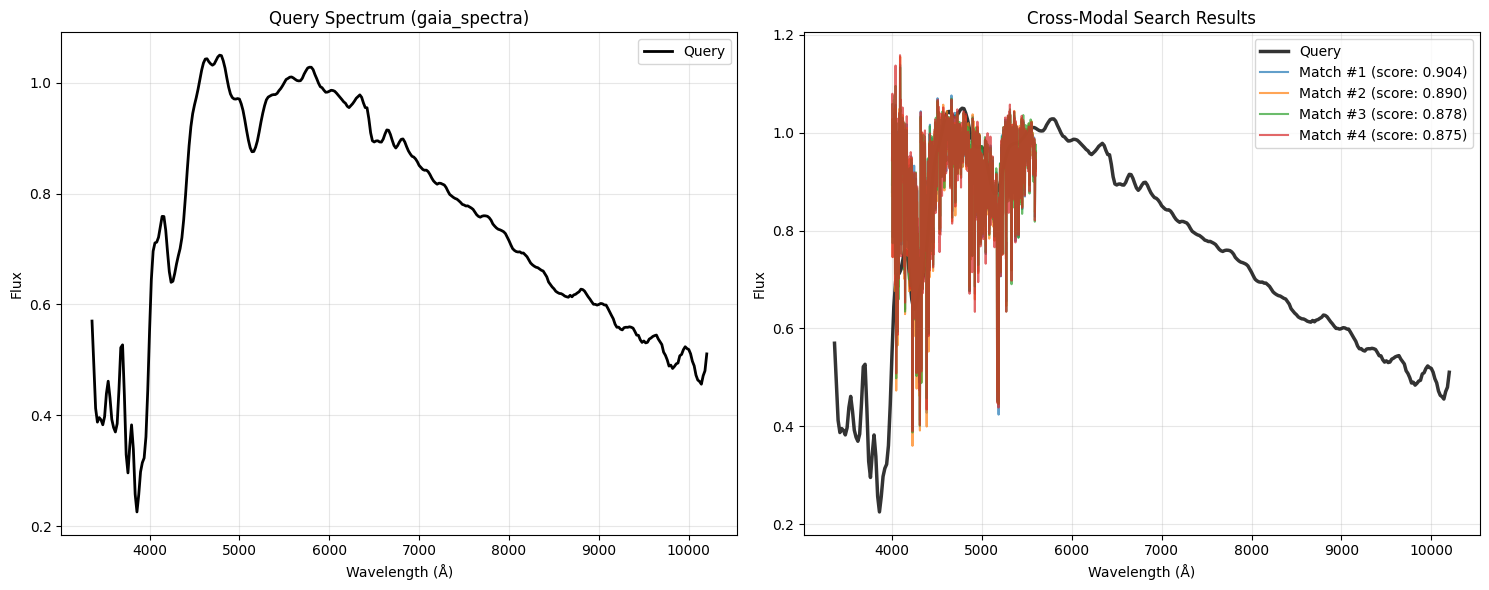

In [15]:
# Gaia query -> Find similar LAMOST spectra
#query_idx = 250
query_idx = 104

results_gaia_to_lamost = retriever.find_similar_spectra(
    query_spectrum=query_idx,
    query_type='gaia_spectra',
    search_type='cross_modal',
    top_k=4,
    exclude_self=False
)

print(f"Gaia Query Index: {query_idx}")
print(f"Top LAMOST match index: {results_gaia_to_lamost['top_indices'][0]}")
print(f"Is paired spectrum the top match? {results_gaia_to_lamost['top_indices'][0] == query_idx}")

retriever.plot_retrieval_results(results_gaia_to_lamost)

### External LAMOST LRS Cross-Modal Retrieval (Task 5)

Cross-modal retrieval: LAMOST → Gaia XP
Top 4 Gaia matches found
Scores: [0.5922396  0.5916445  0.58601004 0.58343524]
Saved plot to ./plots/external_lamost_to_gaia_cross.png


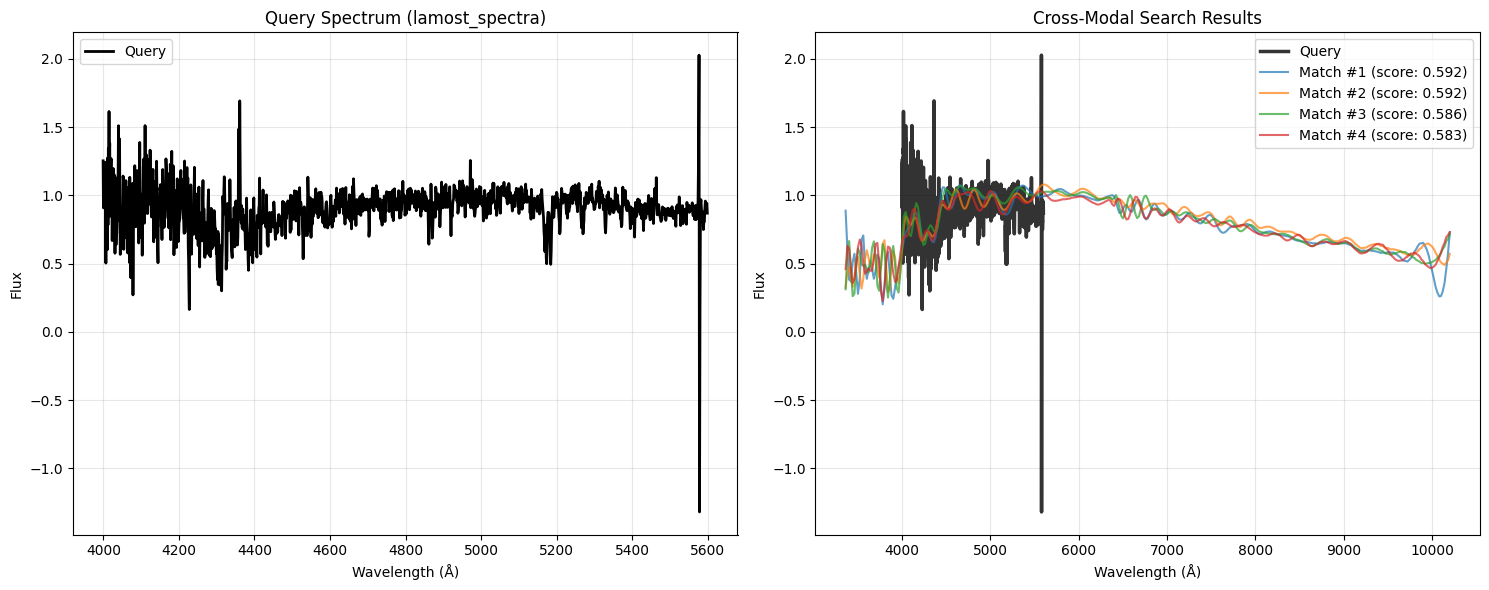

In [16]:
# Load external LAMOST spectrum
wavelength, flux = load_spectrum_data('./test_data/lrs/sample1_matrix.fits')

# Find similar Gaia XP spectra
results_external_cross = retriever.find_similar_spectra(
    query_spectrum=(wavelength, flux),
    query_type='lamost_spectra',
    search_type='cross_modal',
    top_k=4
)

print("Cross-modal retrieval: LAMOST → Gaia XP")
print(f"Top {len(results_external_cross['top_spectra'])} Gaia matches found")
print(f"Scores: {results_external_cross['top_scores']}")

retriever.plot_retrieval_results(
    results_external_cross,
    save_path='./plots/external_lamost_to_gaia_cross.png'
)

### External Gaia XP Cross-Modal Retrieval (Task 5)

Cross-modal retrieval: Gaia XP → LAMOST
Top match score: 0.8911


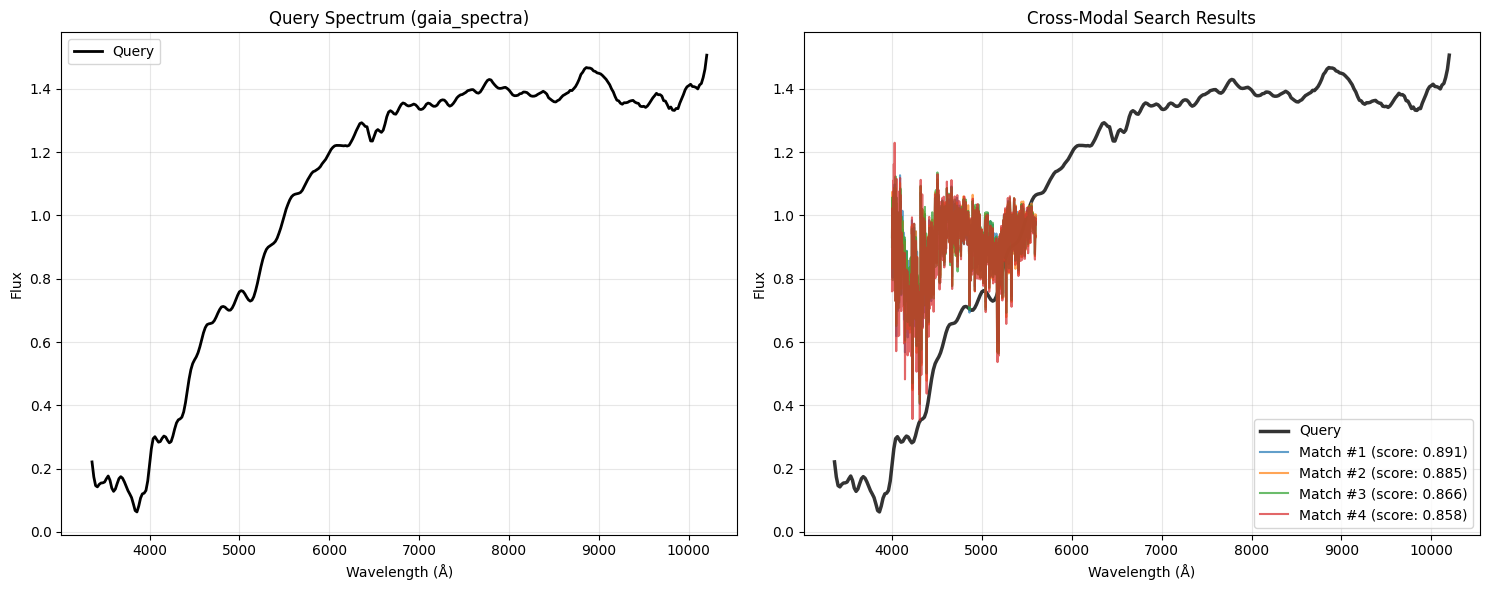

In [17]:
# Load external Gaia XP spectrum
wavelength_xp, flux_xp = load_spectrum_data_xp('./test_data/xp/sample4_txt_xp.csv')

# Find similar LAMOST spectra
results_gaia_cross = retriever.find_similar_spectra(
    query_spectrum=(wavelength_xp, flux_xp),
    query_type='gaia_spectra',
    search_type='cross_modal',
    top_k=4
)

print("Cross-modal retrieval: Gaia XP → LAMOST")
print(f"Top match score: {results_gaia_cross['top_scores'][0]:.4f}")

retriever.plot_retrieval_results(results_gaia_cross)

### Cross-Modal Prediction from Test Set (Task 6)

Query type: lamost_spectra
Predicted type: gaia_spectra
Has ground truth: True
Saved plot to ./plots/lamost_to_gaia_prediction_104.png


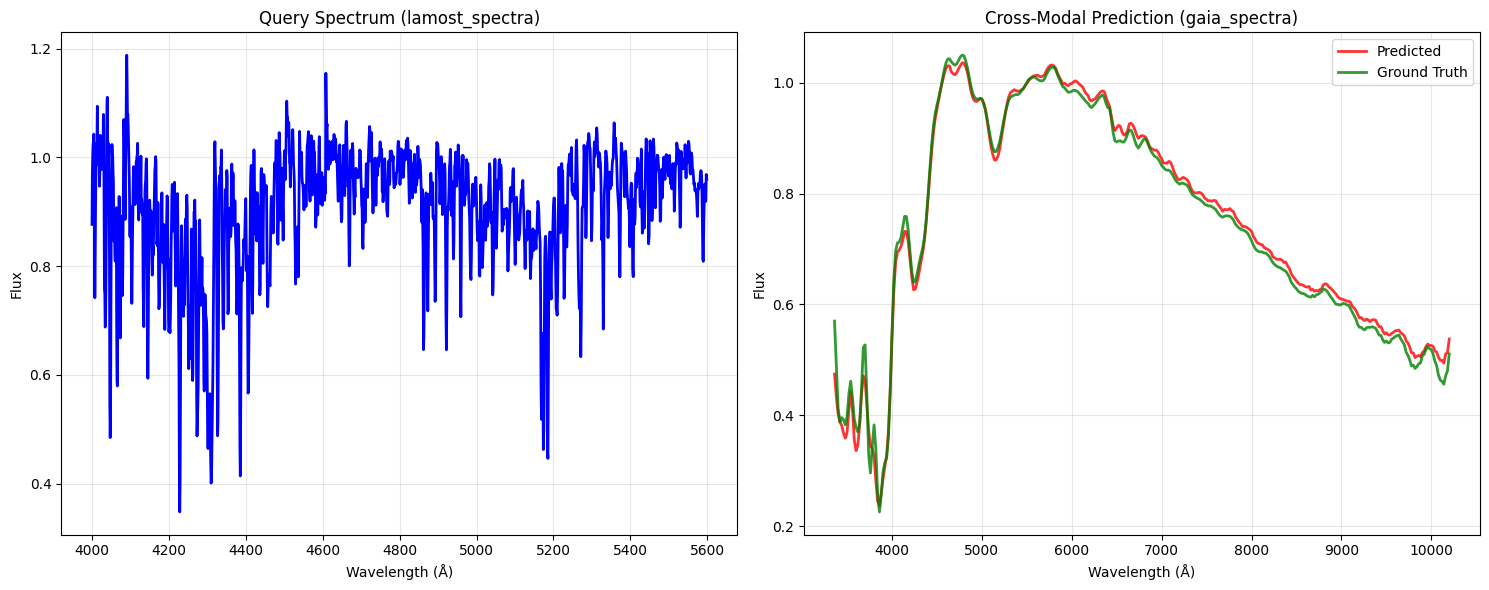

In [18]:
# Predict Gaia spectrum from LAMOST
query_idx = 104 #100

prediction_results = retriever.predict_cross_modal(
    query_spectrum=query_idx,
    query_type='lamost_spectra'
)

print(f"Query type: {prediction_results['query_type']}")
print(f"Predicted type: {prediction_results['predicted_type']}")
print(f"Has ground truth: {prediction_results['ground_truth'] is not None}")

# Plot prediction vs ground truth
retriever.plot_cross_modal_prediction(
    prediction_results,
    save_path=f'./plots/lamost_to_gaia_prediction_{query_idx}.png'
)

Query type: gaia_spectra
Predicted type: lamost_spectra
Has ground truth: True
Saved plot to ./plots/gaia_to_lamost_prediction_104.png


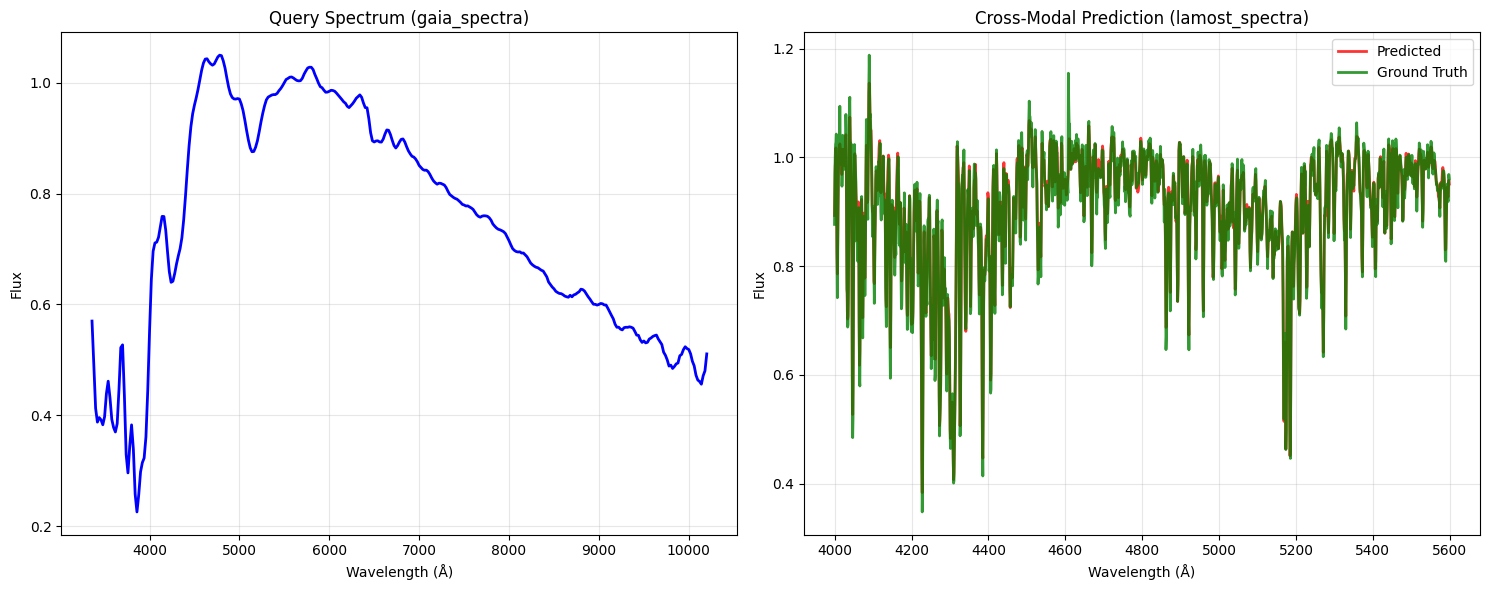

In [20]:
# Predict Gaia spectrum from LAMOST
query_idx = 104 #100

prediction_results = retriever.predict_cross_modal(
    query_spectrum=query_idx,
    query_type='gaia_spectra'
)

print(f"Query type: {prediction_results['query_type']}")
print(f"Predicted type: {prediction_results['predicted_type']}")
print(f"Has ground truth: {prediction_results['ground_truth'] is not None}")

# Plot prediction vs ground truth
retriever.plot_cross_modal_prediction(
    prediction_results,
    save_path=f'./plots/gaia_to_lamost_prediction_{query_idx}.png'
)

### Cross-Modal Prediction - External LAMOST (Task 6)

Predicting Gaia XP spectrum from external LAMOST spectrum
Predicted spectrum shape: (343,)
Saved plot to ./plots/external_lamost_to_gaia_prediction.png


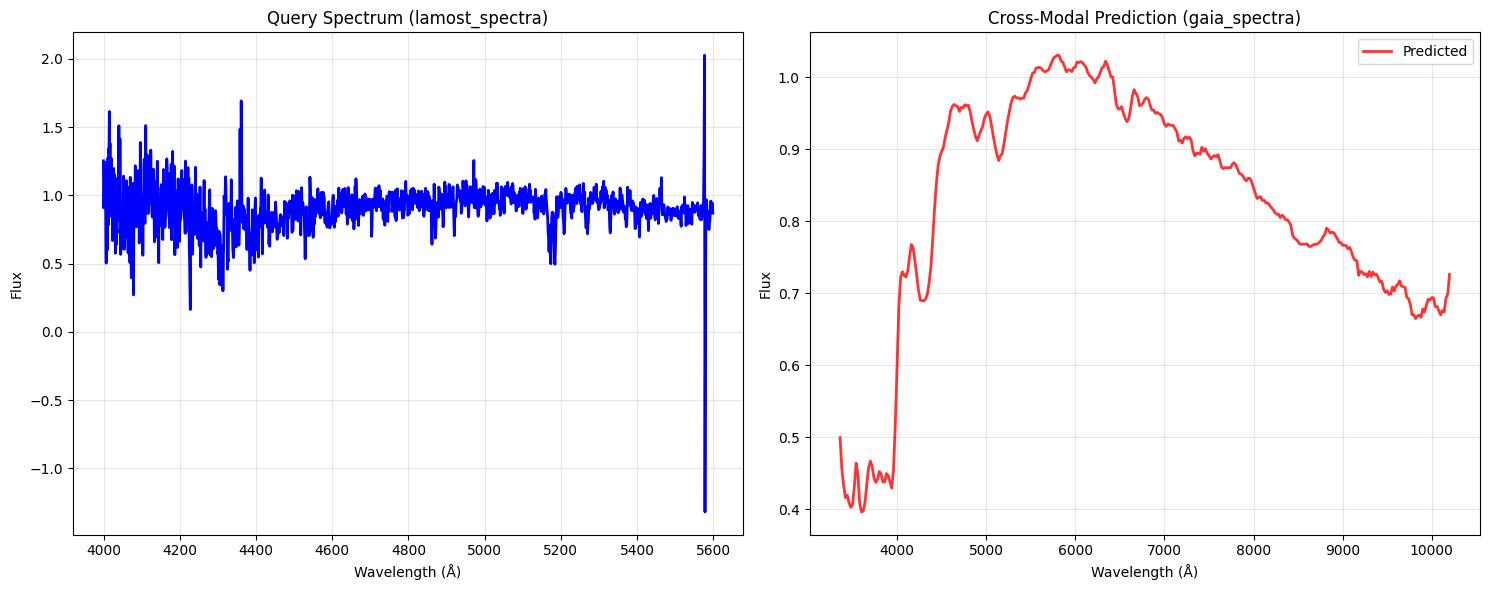

In [74]:
# Load external LAMOST spectrum
wavelength, flux = load_spectrum_data('./test_data/lrs/sample1_matrix.fits')

# Predict corresponding Gaia XP spectrum
prediction_external = retriever.predict_cross_modal(
    query_spectrum=(wavelength, flux),
    query_type='lamost_spectra'
)

print("Predicting Gaia XP spectrum from external LAMOST spectrum")
print(f"Predicted spectrum shape: {prediction_external['predicted_spectrum'].shape}")

retriever.plot_cross_modal_prediction(
    prediction_external,
    save_path='./plots/external_lamost_to_gaia_prediction.png'
)

### Cross-Modal Prediction - External Gaia XP (Task 6)

Predicting LAMOST spectrum from external Gaia XP spectrum
Saved plot to ./plots/external_gaia_to_lamost_prediction.png


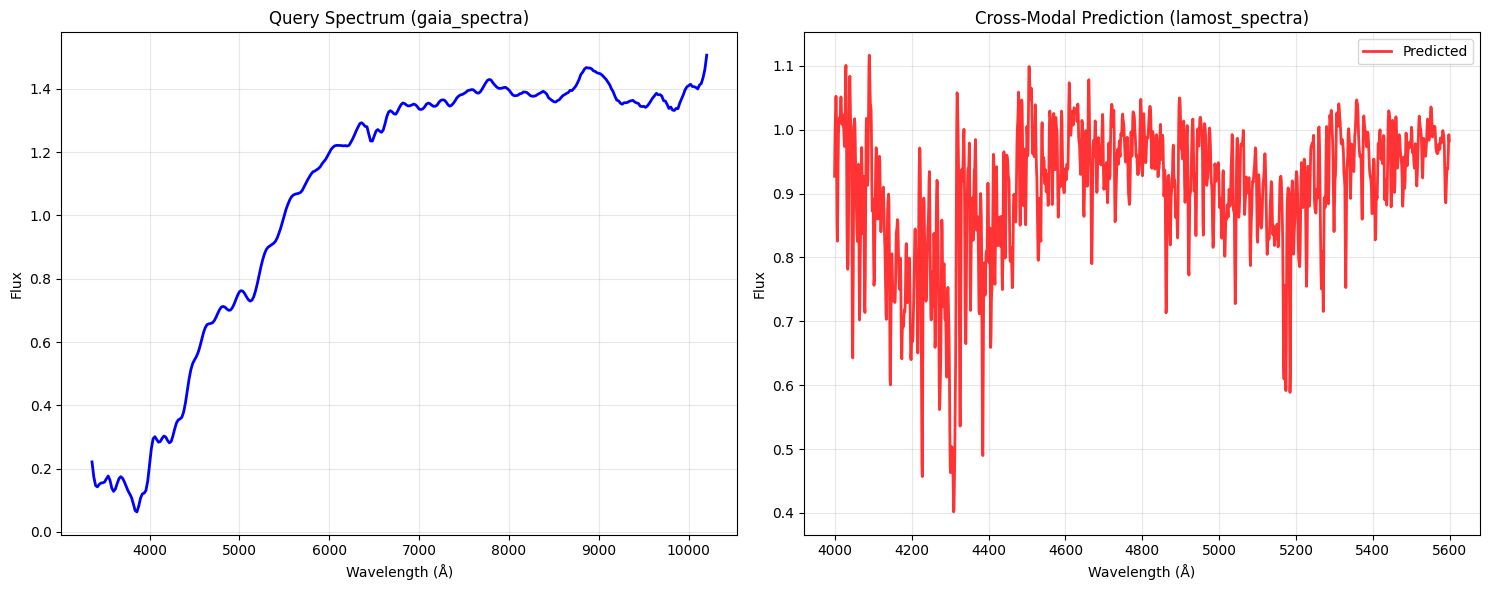

In [22]:
# Load external Gaia XP spectrum
wavelength_xp, flux_xp = load_spectrum_data_xp('./test_data/xp/sample4_txt_xp.csv')

# Predict corresponding LAMOST spectrum
prediction_gaia = retriever.predict_cross_modal(
    query_spectrum=(wavelength_xp, flux_xp),
    query_type='gaia_spectra'
)

print("Predicting LAMOST spectrum from external Gaia XP spectrum")

retriever.plot_cross_modal_prediction(
    prediction_gaia,
    save_path='./plots/external_gaia_to_lamost_prediction.png'
)

### Batch Processing Multiple Queries

In [23]:
# Process multiple queries at once
query_indices = [10, 50, 100, 250, 500]

results_batch = []
for idx in query_indices:
    result = retriever.find_similar_spectra(
        query_spectrum=idx,
        query_type='lamost_spectra',
        search_type='in_modal',
        top_k=4,
        exclude_self=False
    )
    results_batch.append(result)
    print(f"Query {idx}: Top match = {result['top_indices'][0]}, "
          f"Score = {result['top_scores'][0]:.4f}")

Query 10: Top match = 10, Score = 1.0000
Query 50: Top match = 50, Score = 1.0000
Query 100: Top match = 100, Score = 1.0000
Query 250: Top match = 250, Score = 1.0000
Query 500: Top match = 500, Score = 1.0000


### Compare In-Modal vs Cross-Modal Retrieval

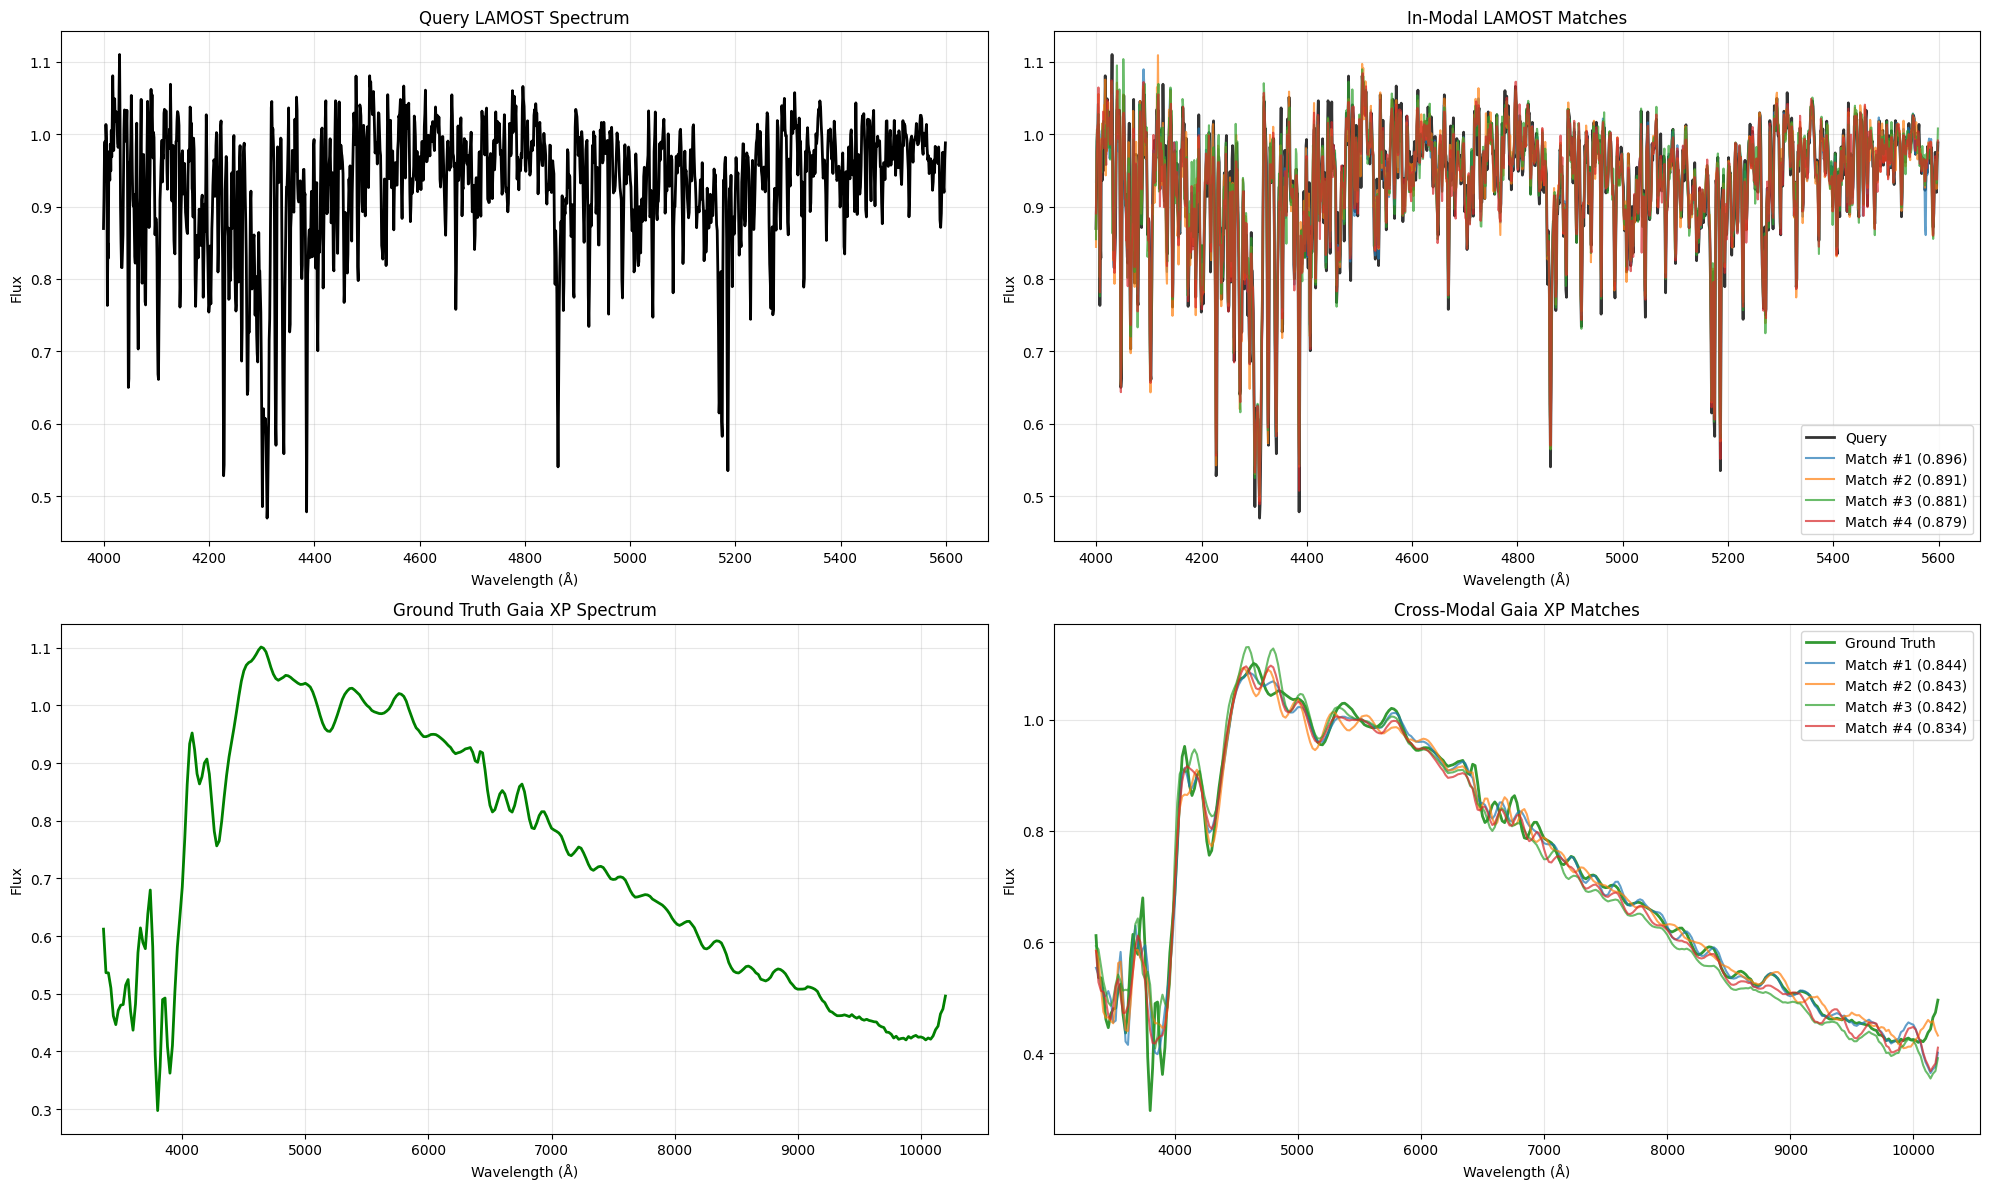

In [24]:
query_idx = 100

# In-modal
in_modal = retriever.find_similar_spectra(
    query_idx, 'lamost_spectra', 'in_modal', top_k=4, exclude_self=True
)

# Cross-modal
cross_modal = retriever.find_similar_spectra(
    query_idx, 'lamost_spectra', 'cross_modal', top_k=4
)

# Plot comparison
fig, axes = plt.subplots(2, 2, figsize=(20, 12))

# Query
axes[0, 0].plot(retriever.lamost_wavelengths, in_modal['query_spectrum'], 'k-', linewidth=2)
axes[0, 0].set_title('Query LAMOST Spectrum')
axes[0, 0].set_xlabel('Wavelength (Å)')
axes[0, 0].set_ylabel('Flux')
axes[0, 0].grid(True, alpha=0.3)

# In-modal matches
axes[0, 1].plot(retriever.lamost_wavelengths, in_modal['query_spectrum'], 
               'k-', linewidth=2, label='Query', alpha=0.8)
for i, (spec, score) in enumerate(zip(in_modal['top_spectra'], in_modal['top_scores'])):
    axes[0, 1].plot(retriever.lamost_wavelengths, spec, linewidth=1.5, alpha=0.7,
                   label=f'Match #{i+1} ({score:.3f})')
axes[0, 1].set_title('In-Modal LAMOST Matches')
axes[0, 1].set_xlabel('Wavelength (Å)')
axes[0, 1].set_ylabel('Flux')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Ground truth Gaia
axes[1, 0].plot(retriever.gaia_wavelengths, retriever.gaia_spectra[query_idx], 
               'g-', linewidth=2)
axes[1, 0].set_title('Ground Truth Gaia XP Spectrum')
axes[1, 0].set_xlabel('Wavelength (Å)')
axes[1, 0].set_ylabel('Flux')
axes[1, 0].grid(True, alpha=0.3)

# Cross-modal matches
axes[1, 1].plot(retriever.gaia_wavelengths, retriever.gaia_spectra[query_idx],
               'g-', linewidth=2, label='Ground Truth', alpha=0.8)
for i, (spec, score) in enumerate(zip(cross_modal['top_spectra'], cross_modal['top_scores'])):
    axes[1, 1].plot(retriever.gaia_wavelengths, spec, linewidth=1.5, alpha=0.7,
                   label=f'Match #{i+1} ({score:.3f})')
axes[1, 1].set_title('Cross-Modal Gaia XP Matches')
axes[1, 1].set_xlabel('Wavelength (Å)')
axes[1, 1].set_ylabel('Flux')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./plots/in_modal_vs_cross_modal_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## ✅ Summary

In this demo, you:

- Loaded the pretrained **SpecCLIP** model toether with the downstream-task models 
- Predicted stellar parameters from a Gaia XP/LAMOST-like spectrum (coming soon)
- Learned how to retrieve similar spectra and predict cross-modal spectra prediction

For more details, check out the [GitHub repo](https://github.com/Xiaosheng-Zhao/SpecCLIP)
and the [paper](https://arxiv.org/abs/2507.01939).